# JATENZO Dose Recommender - XGBoost model

**What this does, in plain terms:** given a patient (age, BMI, current testosterone, current dose) and a *target* testosterone, this model predicts the testosterone the patient would reach at **each** candidate dose, then recommends the dose that gets closest to the target.

This notebook uses the **XGBoost** engine. The XGBoost, LightGBM, and CatBoost notebooks are identical except for the engine, so you can compare them fairly.

Run the cells top to bottom. Each section starts with a short explanation.

## Setup

In [1]:
# --- Setup (run this first) -------------------------------------------------
import os, sys, warnings, numpy as np, pandas as pd
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

ENGINE = "xgboost"          # the model engine this notebook uses

# find the project folder and load the pipeline pieces
REPO = os.getcwd()
while not os.path.isdir(os.path.join(REPO, "src")) and REPO != os.path.dirname(REPO):
    REPO = os.path.dirname(REPO)
sys.path.insert(0, os.path.join(REPO, "src"))

from data import build_abt
from models import OutcomeTModel
from guardrails import directional_dose

print("Ready. Using engine:", ENGINE)


Ready. Using engine: xgboost


## Step 1 - Load the data

Each row is one observation: a patient in some state was given a dose, and we recorded the testosterone they reached.

In [2]:
# Load the data. Uses your cleaned file (data/abt.csv) if present, else a built-in sample.
abt_path = os.path.join(REPO, "data", "abt.csv")
if os.path.exists(abt_path):
    df = build_abt({"source": "file", "abt_path": abt_path})
    print("Loaded cleaned data:", os.path.relpath(abt_path, REPO))
else:
    df = build_abt({"source": "synthetic"})
    print("No cleaned file found - using a built-in SAMPLE so the notebook runs.")

DOSES = sorted(df["new_dose"].unique().tolist())     # candidate doses seen in the data
print(f"{len(df):,} observations from {df['subject_id'].nunique()} patients")
print("Doses used in the trial (mg):", DOSES)
df.head()


Loaded cleaned data: data/abt.csv
511 observations from 287 patients
Doses used in the trial (mg): [158, 198, 237, 316, 396, 474]


,subject_id,age,bmi,current_dose,new_dose,current_T,outcome_T,delta_t,interval_days,is_switch,pair,delta_t_win
0,101-018,48,31.5,316,158,1550.0,121.0,-1429.0,30.0,1,P1: 30-60,-1429.0
1,101-025,40,25.0,316,158,1480.0,292.0,-1188.0,30.0,1,P1: 30-60,-1188.0
2,101-067,51,26.3,316,158,1170.0,1320.0,150.0,30.0,1,P1: 30-60,150.0
3,101-079,63,22.1,316,158,1330.0,827.0,-503.0,30.0,1,P1: 30-60,-503.0
4,102-021,68,27.2,316,158,1350.0,284.0,-1066.0,30.0,1,P1: 30-60,-1066.0


## Step 2 - Train the model

We hold out a fifth of the **patients** entirely, so the model is tested on people it has never seen.

In [3]:
# Split by PATIENT (never split a patient across train/test) and train the model.
from sklearn.model_selection import GroupShuffleSplit
tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=0)
              .split(df, groups=df["subject_id"]))
train, test = df.iloc[tr], df.iloc[te]

FEATURES = ["age", "bmi", "current_T", "new_dose"]   # current dose left out - not important
model = OutcomeTModel({"engine": ENGINE, "features": FEATURES, "target": "outcome_T",
                       "hyperparameters": {"n_estimators": 400,
                                           "learning_rate": 0.05, "max_depth": 3}})
model.fit(train, train["outcome_T"])
print(f"Trained on {len(train)} rows; testing on {len(test)} held-out patients' rows.")
print("Features used:", FEATURES)


Trained on 396 rows; testing on 115 held-out patients' rows.
Features used: ['age', 'bmi', 'current_T', 'new_dose']


## Step 3 - How good is it?

Two fair tests: how accurately it predicts the final testosterone, and how often its dose recommendation matches what actually happened.

In [4]:
# TEST 1 - how well does it predict the final testosterone the patient actually reached?
pred = model.predict(test)
actual = test["outcome_T"].values
rmse = float(np.sqrt(np.mean((actual - pred) ** 2)))
r2   = float(1 - np.sum((actual - pred)**2) / np.sum((actual - actual.mean())**2))

# TEST 2 - if a patient wanted the T they actually achieved, would we recommend the
#          dose they actually took? Focus on rows where the dose was CHANGED - those are
#          the real decisions. (On unchanged-dose rows the answer is trivially "keep it".)
idx = {d: i for i, d in enumerate(DOSES)}
rec = model.recommend(test, actual)
taken = test["new_dose"].values
switch = test["is_switch"].values == 1
def within1(mask):
    a, b = rec[mask], taken[mask]
    return float(np.mean([abs(idx[x]-idx[y]) <= 1 for x, y in zip(a, b)])) if mask.sum() else float("nan")

print("HOW WELL IT PREDICTS FINAL TESTOSTERONE")
print(f"   Typical miss (RMSE): {rmse:,.0f} ng/dL")
print(f"   R-squared: {r2:.2f}  (= explains {r2*100:.0f}% of the variation; 1.0 is perfect, 0 = no better than the average)")
print()
print("DOSE RECOMMENDATION - within one step of what actually happened")
print(f"   On DOSE-CHANGE decisions (what matters): {within1(switch)*100:.0f}%")
print(f"   On all rows:                             {within1(np.ones(len(rec),bool))*100:.0f}%")
print(f"   Rows where the dose was actually changed: {int(switch.sum())} of {len(test)}")


HOW WELL IT PREDICTS FINAL TESTOSTERONE
   Typical miss (RMSE): 444 ng/dL
   R-squared: -0.19  (= explains -19% of the variation; 1.0 is perfect, 0 = no better than the average)

DOSE RECOMMENDATION - within one step of what actually happened
   On DOSE-CHANGE decisions (what matters): 49%
   On all rows:                             46%
   Rows where the dose was actually changed: 41 of 115


### The full scorecard

Two tables in the team's standard format. **R² (delta T)** is the honest headline: it scores how well we predict the *change* in testosterone (what the dose actually drives), rather than the raw final level, whose variance is dominated by noise.

In [5]:
# The team's standard scorecard (two tables). R2 (delta T) is the honest read - it scores
# predicting the CHANGE in testosterone, which is what the model actually influences.
import report as report_mod
cfg_min = {"data": {"source": "file", "abt_path": os.path.join(REPO, "data", "abt.csv")},
           "model": {"name": "outcome_t", "engine": ENGINE, "features": FEATURES,
                     "hyperparameters": {"n_estimators": 400, "learning_rate": 0.05, "max_depth": 3}},
           "experiment": {"seed": 42}}
stat, rec, beh = report_mod.build_report(cfg_min)
print("STATISTICAL ACCURACY  (predicting testosterone)")
display(stat.round(3))
print("DOSE-RECOMMENDATION ACCURACY  (does the recommender match reality?)")
display(rec.round(1))
print("DOSING BEHAVIOR  (over/under-dosing, mis-dose rate, multi-rung jumps)")
display(beh.round(1))


STATISTICAL ACCURACY  (predicting testosterone)


,n,R2 (final T),R2 (delta T),RMSE,MAE,MSE,% within 150
In-sample (full-data fit),511.0,0.706,0.873,214.727,165.071,46107.682,55.773
"Out-of-sample (CV, out-of-fold)",422.0,-0.134,0.457,419.970,298.334,176374.806,36.256
Out-of-sample (held-out patients),89.0,-0.169,0.642,437.973,310.863,191820.729,32.584


DOSE-RECOMMENDATION ACCURACY  (does the recommender match reality?)


,n,Exact %,Within 1 step %,n (clean),Exact % (clean),Within 1 step % (clean)
"In-sample (production model, full data)",511.0,24.9,53.2,498.0,23.7,52.8
Out-of-sample (held-out patients),89.0,21.3,41.6,86.0,20.9,41.9


DOSING BEHAVIOR  (over/under-dosing, mis-dose rate, multi-rung jumps)


,n,% over,% under,% exact,% mis-dosed,% >1 rung from current
In-sample (full-data fit),511.0,30.7,44.4,24.9,75.1,48.9
"Full sample (CV, out-of-fold)",511.0,32.9,51.5,15.7,84.3,58.1
Out-of-sample (held-out patients),89.0,30.3,48.3,21.3,78.7,60.7


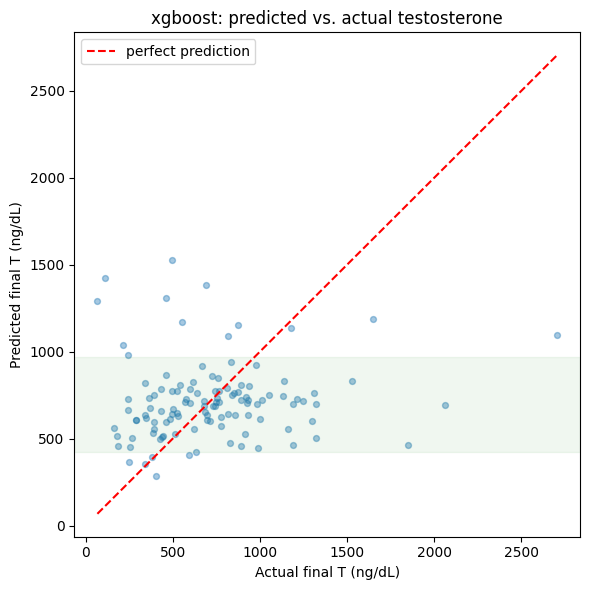

In [6]:
# Picture: predicted vs. actual final testosterone. Closer to the diagonal line = better.
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(actual, pred, alpha=0.4, s=18)
lims = [min(actual.min(), pred.min()), max(actual.max(), pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="perfect prediction")
ax.axhspan(425, 970, color="green", alpha=0.06)
ax.set_xlabel("Actual final T (ng/dL)"); ax.set_ylabel("Predicted final T (ng/dL)")
ax.set_title(f"{ENGINE}: predicted vs. actual testosterone")
ax.legend(); plt.tight_layout(); plt.show()


## Step 4 - Recommend a dose for a patient

This is the actual product: try every dose, predict the outcome, pick the closest to the goal.

Patient: age 40, BMI 25.0, current T 1480.0, on 316 mg. Goal: 500 ng/dL.


,dose_mg,predicted_final_T,distance_to_goal
0,158,608,108
1,198,1112,612
2,237,928,428
3,316,1103,603
4,396,992,492
5,474,1049,549


--> Model's pick (closest to goal): 158 mg


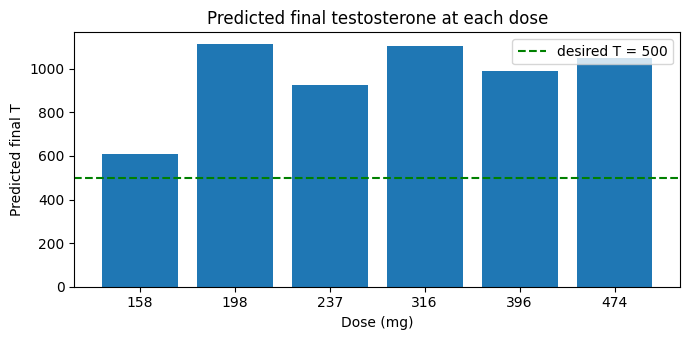

In [7]:
# Recommend a dose for one example patient (taken from the real held-out data).
# The model tries every dose, predicts the resulting T for each, and picks the one
# closest to the patient's desired testosterone.
row = test.iloc[0]
patient = {"age": int(row["age"]), "bmi": round(float(row["bmi"]), 1),
           "current_T": float(row["current_T"]), "current_dose": int(row["current_dose"])}
desired_T = 500      # where we want this patient to land (ng/dL) - a healthy mid-range

table = pd.DataFrame([{"dose_mg": d,
                       "predicted_final_T":
                           round(float(model.predict(pd.DataFrame([{**patient, "new_dose": d}]))[0]))}
                      for d in DOSES])
table["distance_to_goal"] = (table["predicted_final_T"] - desired_T).abs()
best = int(table.sort_values("distance_to_goal").iloc[0]["dose_mg"])

print(f"Patient: age {patient['age']}, BMI {patient['bmi']}, "
      f"current T {patient['current_T']}, on {patient['current_dose']} mg. Goal: {desired_T} ng/dL.")
display(table)
print(f"--> Model's pick (closest to goal): {best} mg")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(table["dose_mg"].astype(str), table["predicted_final_T"])
ax.axhline(desired_T, color="green", linestyle="--", label=f"desired T = {desired_T}")
ax.set_xlabel("Dose (mg)"); ax.set_ylabel("Predicted final T"); ax.legend()
ax.set_title("Predicted final testosterone at each dose"); plt.tight_layout(); plt.show()


## Step 5 - Guardrails

The guardrails are a plain-English safety net applied **after** the model, so the recommendation always moves in the sensible direction:

1. **New patient** -> use the model's dose chosen to reach the goal (a low-T patient who needs a big rise is NOT forced to a low fixed start). A conservative 'label start' option also exists.
2. **Keep T the same** -> keep the current dose.
3. **Want higher T** -> the dose must go up (a big jump toward the goal is allowed).
4. **Want lower T** -> the dose must go down.

They never invent a dose - they only correct the direction of the model's suggestion.

In [8]:
# Guardrails: a simple safety layer that makes the recommendation's DIRECTION sensible.
# It runs AFTER the model and only corrects the direction - it never invents a dose.
START = 237 if 237 in DOSES else DOSES[len(DOSES)//2]
def show(label, proposed, cur_dose, cur_T, want_T, naive_policy="model"):
    d = directional_dose(proposed, cur_dose, cur_T, want_T, ladder=DOSES,
                         start_dose=START, naive_policy=naive_policy)
    print(f"{label:46s} -> {d.dose:>3} mg   ({d.rationale})")

print("GUARDRAILS (doses:", DOSES, ")\n")
# The naive question: a low-T patient who wants a BIG rise should NOT be forced to a low
# fixed start. With naive_policy='model' the model picks the dose to reach the goal.
show("1a. Naive + wants big rise (model policy)",  396, 0,   150, 900)
show("1b. Naive + wants big rise (label start)",   396, 0,   150, 900, naive_policy="standard_start")
show("2.  Want to KEEP T the same",                237, 237, 600, 610)
show("3.  Want HIGHER T (force step up)",          158, 237, 400, 900)
show("4.  Want LOWER T (force step down)",         396, 316, 900, 400)


GUARDRAILS (doses: [158, 198, 237, 316, 396, 474] )

1a. Naive + wants big rise (model policy)      -> 396 mg   (Treatment-naive: model-recommended starting dose (chosen to reach the target T).)
1b. Naive + wants big rise (label start)       -> 237 mg   (Treatment-naive: label's standard start dose.)
2.  Want to KEEP T the same                    -> 237 mg   (Goal is to maintain T: keep current dose.)
3.  Want HIGHER T (force step up)              -> 316 mg   (Goal is higher T: dose stepped up.)
4.  Want LOWER T (force step down)             -> 237 mg   (Goal is lower T: dose stepped down.)


## Summary

The **XGBoost** model predicts final testosterone at each dose and recommends the one closest to the target, with guardrails keeping the direction sensible. Swap this notebook for the XGBoost / LightGBM / CatBoost version to compare engines on the same data.

*Numbers here use a built-in sample until the real cleaned data (`data/abt.csv`) is added - then re-run and the numbers update.*